# Calibration of $\vartheta$ prior distribution

With the reference being Harding et al (2023), we derive priors on our regional climate model parameters that result in a similar distribution.

## A word of caution
This is a "scratch" notebook to do the calibration -- numbers reported in the paper or used in the analysis are found if you restart the kernel and run from scratch. Some variable names are reused, changed later, and/or altered throughout. Be careful rerunning cells!

In [1]:
import argparse

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb

from scipy.stats import describe, gaussian_kde

from var_assim.plotting.presets import get_presets
from var_assim.plotting.utils import make_figure_filename
from var_assim.plotting.pproc import get_angle_r2, get_angle_r3
from var_assim.calibration.priors import ClimateModelPriors
from var_assim.calibration.noise import ClimateModelNoise
from var_assim.config import NOISE_PATH, PRIOR_PATH, FIGS_DIR

presets, _ = get_presets()
plt.rcParams.update(presets)

# enable auto reload
%load_ext autoreload
%autoreload 2

SAVE_FIGS = True

In [2]:
# high level parameters
N_SAMPLES = 100000
SEED = 42

## Setup Harding et al. (2023) baseline

In [3]:
# harding parameters
MU_HARDING = (np.log(5) + np.log(30)) / 2 
SIGMA_HARDING = np.log(30 / 5) / (2 * 1.645)

# generate random samples from harding
rng = np.random.default_rng(SEED)
theta_harding = rng.lognormal(mean=MU_HARDING, sigma=SIGMA_HARDING, size=N_SAMPLES)

In [4]:
SAMPLE_MEDIAN = np.median(theta_harding)
SAMPLE_MEAN = np.mean(theta_harding)
SAMPLE_5_PERCENTILE = np.percentile(theta_harding, 5)
SAMPLE_95_PERCENTILE = np.percentile(theta_harding, 95)

print(f"Sample median: {SAMPLE_MEDIAN}")
print(f"Sample mean: {SAMPLE_MEAN}")
print(f"Sample 5th percentile: {SAMPLE_5_PERCENTILE}")
print(f"Sample 95th percentile: {SAMPLE_95_PERCENTILE}")

Sample median: 12.187540373107769
Sample mean: 14.192127373062506
Sample 5th percentile: 4.963788517804812
Sample 95th percentile: 30.024411858004793


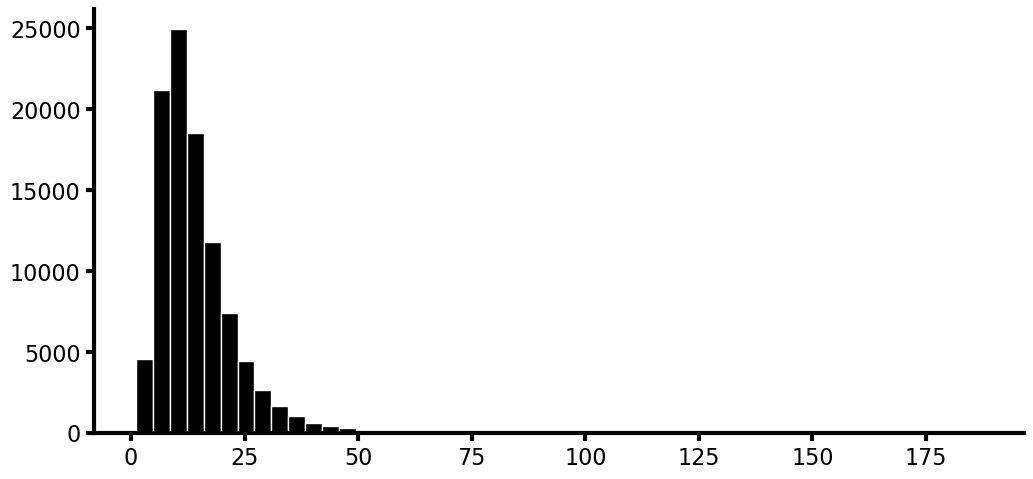

In [5]:
plt.hist(theta_harding, bins=50)
plt.show()

In [6]:
# check reported vs empirical attributes
HARDING_MEDIAN_REPORTED = 15
HARDING_95_REPORTED = 30
HARDING_5_REPORTED = 5

print(f"Difference between empirical and reported median: {np.median(theta_harding) - HARDING_MEDIAN_REPORTED}")
print(f"Difference between empirical and reported 95 percentiles: {np.percentile(theta_harding, 95) - HARDING_95_REPORTED}")
print(f"Difference between empirical and reported 5 percentiles: {np.percentile(theta_harding, 5) - HARDING_5_REPORTED}")

Difference between empirical and reported median: -2.812459626892231
Difference between empirical and reported 95 percentiles: 0.024411858004793174
Difference between empirical and reported 5 percentiles: -0.03621148219518844


## My model prior building

### 2 region

In [7]:
# make dummy namespace for prior class initialization
cli_r2 = argparse.Namespace(
    model='pco2geowc',
    ssp='ssp245',
    noise_model='AR1',
    tmin=2023,
    theta=14,
    AR=1,
    ecs=3.0,
    DEGpDEC=0.1,
    NYRSRAMP=50,
    Nens=1000,
    reg_noise=False,
    windowing='ws_gradual'
)

In [8]:
Noise = ClimateModelNoise.from_cli_and_yaml(cli_r2, NOISE_PATH)

In [9]:
Prior_r2 = ClimateModelPriors.from_cli_and_yaml_and_noise(
    cli_r2, PRIOR_PATH, Noise
)

In [10]:
# global parameters
Ls = np.random.normal(loc=Prior_r2.L_CEN, scale=Prior_r2.L_STD, size=N_SAMPLES)
Gs = np.random.normal(loc=Prior_r2.G_CEN, scale=Prior_r2.G_STD, size=N_SAMPLES)
EPSs = np.random.normal(loc=Prior_r2.EPS_CEN, scale=Prior_r2.EPS_STD, size=N_SAMPLES)

UNC_ADJ = 1.
MED_ADJ = 1.

A1s = np.random.normal(loc=Prior_r2.ALPHA_CEN[0], scale=Prior_r2.ALPHA_STD[0], size=N_SAMPLES)
A2s = np.random.normal(loc=Prior_r2.ALPHA_CEN[1], scale=Prior_r2.ALPHA_STD[1], size=N_SAMPLES)

B1s = np.random.normal(loc=Prior_r2.BETA_CEN[0] * MED_ADJ, scale=Prior_r2.BETA_STD[0] * UNC_ADJ, size=N_SAMPLES)
B2s = np.random.normal(loc=Prior_r2.BETA_CEN[1] * MED_ADJ, scale=Prior_r2.BETA_STD[1] * UNC_ADJ, size=N_SAMPLES)

In [11]:
print(f"This parameter setup is:")
print(f"   A1: cen={Prior_r2.ALPHA_CEN[0]}, std={Prior_r2.ALPHA_STD[0]}")
print(f"   A2: cen={Prior_r2.ALPHA_CEN[1]}, std={Prior_r2.ALPHA_STD[1]}")
print(f"   B1: cen={Prior_r2.BETA_CEN[0] * MED_ADJ}, std={Prior_r2.BETA_STD[0] * UNC_ADJ}")
print(f"   B2: cen={Prior_r2.BETA_CEN[1] * MED_ADJ}, std={Prior_r2.BETA_STD[1] * UNC_ADJ}")

This parameter setup is:
   A1: cen=1.6, std=0.2816
   A2: cen=1.3, std=0.2288
   B1: cen=-0.01812132, std=0.010648
   B2: cen=0.01812132, std=0.010648


In [12]:
theta_me = np.array([get_angle_r2(A1, A2, B1, B2, L, EPS, G)
                     for A1, A2, B1, B2, L, EPS, G
                     in zip(A1s, A2s, B1s, B2s, Ls, EPSs, Gs)])

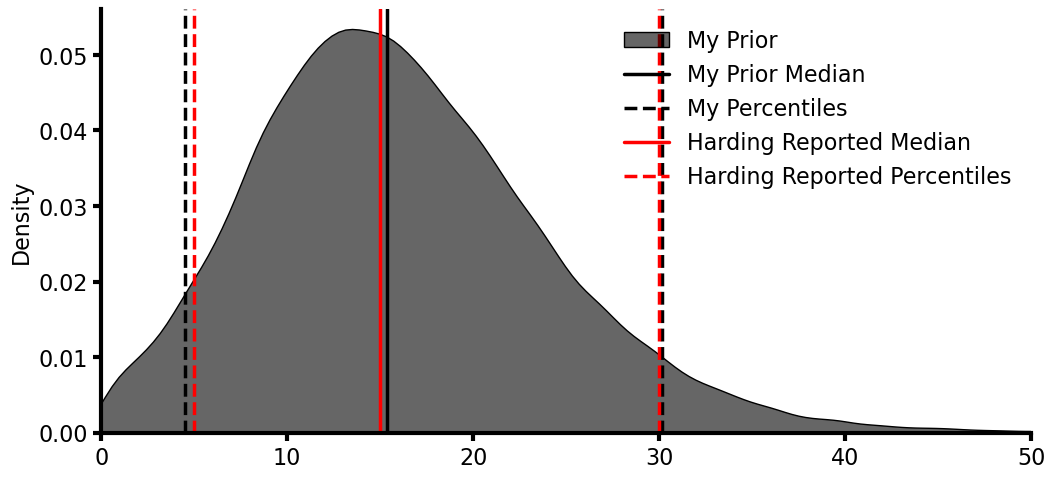

In [13]:
sb.kdeplot(theta_me, fill=True, alpha=0.6, label='My Prior')
# sb.kdeplot(theta_harding, fill=True, alpha=0.6, label='Harding et al (2023)')

plt.xlim((0, 50))
plt.axvline(np.median(theta_me), label='My Prior Median', color='k', linestyle='solid')
plt.axvline(np.percentile(theta_me, 5), label='My Percentiles', color='k', linestyle='dashed')
plt.axvline(np.percentile(theta_me, 95), color='k', linestyle='dashed')

plt.axvline(HARDING_MEDIAN_REPORTED, label='Harding Reported Median', color='r', linestyle='solid')
plt.axvline(HARDING_95_REPORTED, label='Harding Reported Percentiles', color='r', linestyle='dashed')
plt.axvline(HARDING_5_REPORTED, color='r', linestyle='dashed')

plt.legend()
plt.show()

In [14]:
print(f"My prior's median: {np.median(theta_me)}")
print(f"My prior's 5th percentile: {np.percentile(theta_me, 5)}")
print(f"My prior's 95th percentile: {np.percentile(theta_me, 95)}")

print(f"Difference between my prior and Harding (median): {np.median(theta_me) - np.median(theta_harding)}")
print(f"Difference between my prior and Harding (5th percentile): {np.percentile(theta_me, 5) - np.percentile(theta_harding, 5)}")
print(f"Difference between my prior and Harding (95th percentile): {np.percentile(theta_me, 95) - np.percentile(theta_harding, 95)}")

My prior's median: 15.367868838331251
My prior's 5th percentile: 4.534194575646935
My prior's 95th percentile: 30.174248807369015
Difference between my prior and Harding (median): 3.1803284652234822
Difference between my prior and Harding (5th percentile): -0.4295939421578767
Difference between my prior and Harding (95th percentile): 0.14983694936422154


### 3 region

In [15]:
# make dummy namespace for prior class initialization
cli_r3 = argparse.Namespace(
    model='pco2geowc3',
    ssp='ssp245',
    noise_model='AR1',
    tmin=2023,
    theta=14,
    AR=1,
    ecs=3.0,
    DEGpDEC=0.1,
    NYRSRAMP=50,
    Nens=1000,
    reg_noise=False,
    windowing='ws_gradual'
)

Noise_r3 = ClimateModelNoise.from_cli_and_yaml(cli_r3, NOISE_PATH)

Prior_r3 = ClimateModelPriors.from_cli_and_yaml_and_noise(
    cli_r3, PRIOR_PATH, Noise_r3
)

In [16]:
# global parameters
Ls = np.random.normal(loc=Prior_r3.L_CEN, scale=Prior_r3.L_STD, size=N_SAMPLES)
Gs = np.random.normal(loc=Prior_r3.G_CEN, scale=Prior_r3.G_STD, size=N_SAMPLES)
EPSs = np.random.normal(loc=Prior_r3.EPS_CEN, scale=Prior_r3.EPS_STD, size=N_SAMPLES)

# regional parameters
MED_ADJ_FACTOR = 1.
UNC_ADJ_FACTOR = 1.

A1s = np.random.normal(loc=Prior_r3.ALPHA_CEN[0], scale=Prior_r3.ALPHA_STD[0], size=N_SAMPLES)
A2s = np.random.normal(loc=Prior_r3.ALPHA_CEN[1], scale=Prior_r3.ALPHA_STD[1], size=N_SAMPLES)
A3s = np.random.normal(loc=Prior_r3.ALPHA_CEN[2], scale=Prior_r3.ALPHA_STD[2], size=N_SAMPLES)

B1s = np.random.normal(loc=Prior_r3.BETA_CEN[0] * MED_ADJ_FACTOR, scale=Prior_r3.BETA_STD[0] * UNC_ADJ_FACTOR, size=N_SAMPLES)
B2s = np.random.normal(loc=Prior_r3.BETA_CEN[1] * MED_ADJ_FACTOR, scale=Prior_r3.BETA_STD[1] * UNC_ADJ_FACTOR, size=N_SAMPLES)
B3s = np.random.normal(loc=Prior_r3.BETA_CEN[2] * MED_ADJ_FACTOR, scale=Prior_r3.BETA_STD[2] * UNC_ADJ_FACTOR, size=N_SAMPLES)

In [17]:
print(f"This parameter setup is:")
print(f"   A1: cen={Prior_r3.ALPHA_CEN[0]}, std={Prior_r3.ALPHA_STD[0]}")
print(f"   A2: cen={Prior_r3.ALPHA_CEN[1]}, std={Prior_r3.ALPHA_STD[1]}")
print(f"   A2: cen={Prior_r3.ALPHA_CEN[2]}, std={Prior_r3.ALPHA_STD[2]}")
print(f"   B1: cen={Prior_r3.BETA_CEN[0] * MED_ADJ_FACTOR}, std={Prior_r3.BETA_STD[0] * UNC_ADJ_FACTOR}")
print(f"   B2: cen={Prior_r3.BETA_CEN[1] * MED_ADJ_FACTOR}, std={Prior_r3.BETA_STD[1] * UNC_ADJ_FACTOR}")
print(f"   B2: cen={Prior_r3.BETA_CEN[2] * MED_ADJ_FACTOR}, std={Prior_r3.BETA_STD[2] * UNC_ADJ_FACTOR}")

This parameter setup is:
   A1: cen=1.6, std=0.32
   A2: cen=1.3, std=0.26
   A2: cen=1.275, std=0.255
   B1: cen=-0.018414, std=0.0143
   B2: cen=0.018414, std=0.0143
   B2: cen=-0.01023, std=0.0143


In [18]:
theta_me_r3 = np.array([get_angle_r3(A1, A2, A3, B1, B2, B3, L, EPS, G)
                     for A1, A2, A3, B1, B2, B3, L, EPS, G
                     in zip(A1s, A2s, A3s, B1s, B2s, B3s, Ls, EPSs, Gs)])

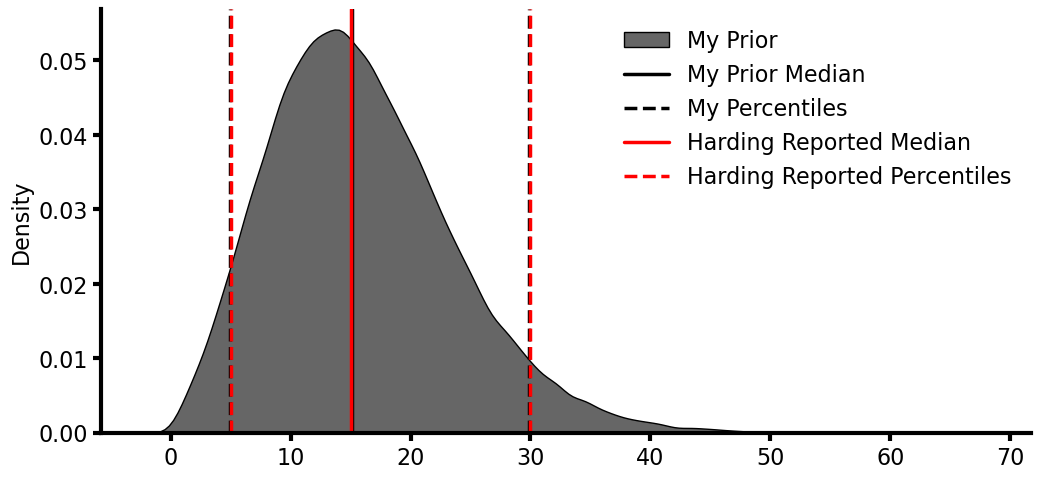

In [19]:
sb.kdeplot(theta_me_r3, fill=True, alpha=0.6, label='My Prior')
#sb.kdeplot(theta_harding, fill=True, alpha=0.6, label='Harding et al (2023)')

#plt.xlim((0, 50))
plt.axvline(np.median(theta_me_r3), label='My Prior Median', color='k', linestyle='solid')
plt.axvline(np.percentile(theta_me_r3, 5), label='My Percentiles', color='k', linestyle='dashed')
plt.axvline(np.percentile(theta_me_r3, 95), color='k', linestyle='dashed')

plt.axvline(HARDING_MEDIAN_REPORTED, label='Harding Reported Median', color='r', linestyle='solid')
plt.axvline(HARDING_95_REPORTED, label='Harding Reported Percentiles', color='r', linestyle='dashed')
plt.axvline(HARDING_5_REPORTED, color='r', linestyle='dashed')

plt.legend()
plt.show()

In [20]:
print(f"My prior's median: {np.median(theta_me_r3)}")
print(f"My prior's 5th percentile: {np.percentile(theta_me_r3, 5)}")
print(f"My prior's 95th percentile: {np.percentile(theta_me_r3, 95)}")

print(f"Difference between my prior and Harding (median): {np.median(theta_me_r3) - np.median(theta_harding)}")
print(f"Difference between my prior and Harding (5th percentile): {np.percentile(theta_me_r3, 5) - np.percentile(theta_harding, 5)}")
print(f"Difference between my prior and Harding (95th percentile): {np.percentile(theta_me_r3, 95) - np.percentile(theta_harding, 95)}")

My prior's median: 15.092511708076238
My prior's 5th percentile: 4.911822409183637
My prior's 95th percentile: 29.86235346422947
Difference between my prior and Harding (median): 2.9049713349684687
Difference between my prior and Harding (5th percentile): -0.051966108621174456
Difference between my prior and Harding (95th percentile): -0.16205839377532172


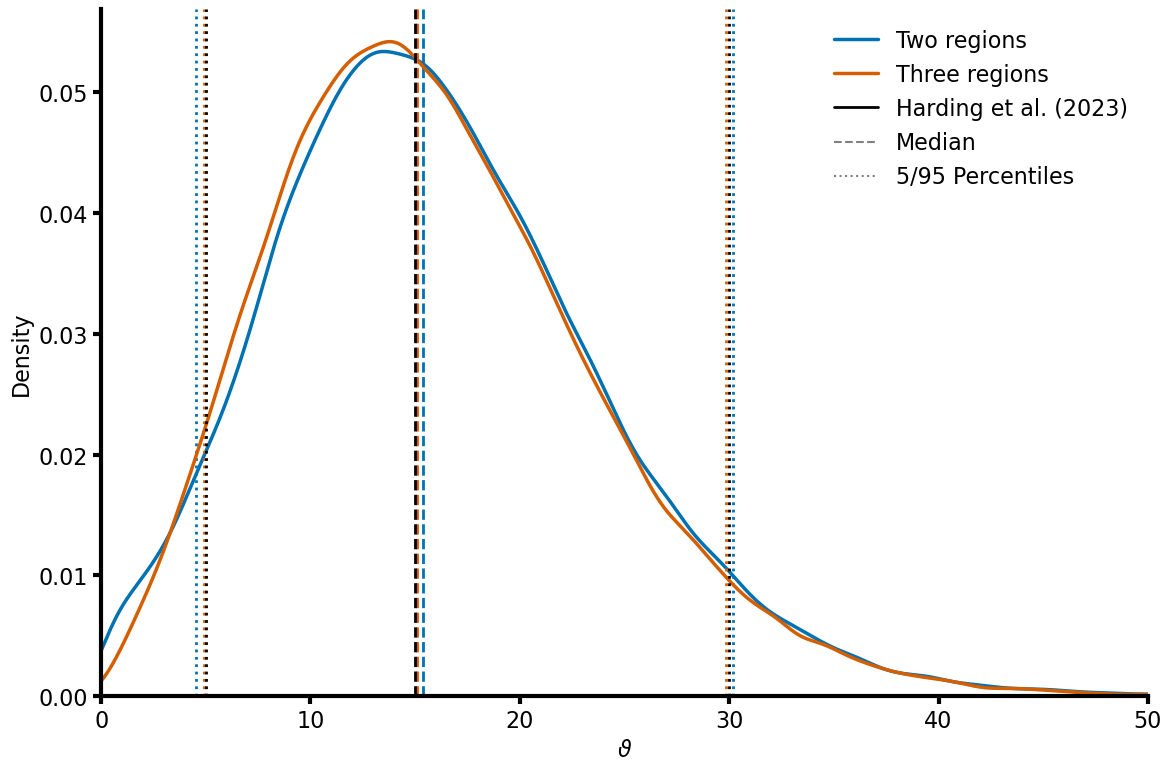

In [21]:
fig, ax = plt.subplots(figsize=(12, 8))

xlims = (0, 50)
xvals = np.linspace(xlims[0], xlims[1], 1000)

# plot my KDEs and vertical lines 
for sample, color, label in zip([theta_me, theta_me_r3], ['#0072B2', '#D55E00'], ['Two regions', 'Three regions']):
    kde = gaussian_kde(sample.flatten())
    ax.plot(xvals, kde(xvals), color=color, linestyle='solid', label=label)
    ax.axvline(np.median(sample), color=color, linestyle='dashed', linewidth=2)
    ax.axvline(np.percentile(sample, 5), color=color, linestyle='dotted', linewidth=2)
    ax.axvline(np.percentile(sample, 95), color=color, linestyle='dotted', linewidth=2)

# add harding estimates
ax.axvline(HARDING_MEDIAN_REPORTED, color='black', linestyle='dashed', linewidth=2)
ax.axvline(HARDING_5_REPORTED, color='black', linestyle='dotted', linewidth=2)
ax.axvline(HARDING_95_REPORTED, color='black', linestyle='dotted', linewidth=2)

# --- dummy legend entries ---
ax.plot([], [], color='black', linestyle='-',  linewidth=2, label='Harding et al. (2023)')
ax.plot([], [], color='grey',  linestyle='--', linewidth=1.5, label='Median')
ax.plot([], [], color='grey',  linestyle=':',  linewidth=1.5, label='5/95 Percentiles')

ax.set_xlabel(r'$\vartheta$')
ax.set_ylabel('Density')
ax.legend()
ax.set_xlim(xlims)
ax.set_ylim((0, None))
plt.tight_layout()

if SAVE_FIGS:
    plt.savefig(make_figure_filename('theta_prior_comparison', FIGS_DIR / 'cal'), bbox_inches='tight')

plt.show()

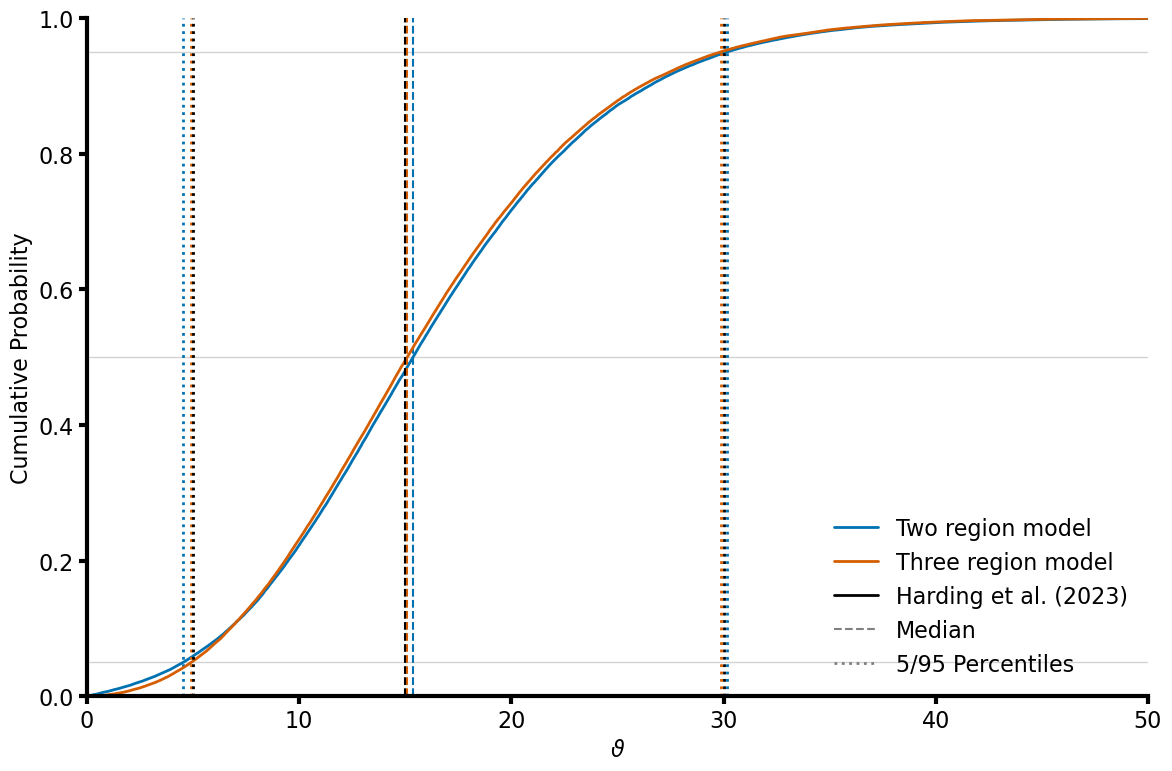

In [22]:
from pathlib import Path

def plot_cdf_comparison(
    theta_me: np.ndarray,
    theta_me_r3: np.ndarray,
    harding_median: float = 15,
    harding_p5: float = 5,
    harding_p95: float = 30,
    xlim: tuple = (0, 50),
    save: bool = False,
    figs_dir: Path | None = None,
) -> tuple[plt.Figure, plt.Axes]:

    fig, ax = plt.subplots(figsize=(12, 8))

    for sample, color, label in zip(
        [theta_me, theta_me_r3],
        ['#0072B2', '#D55E00'],
        ['Two region model', 'Three region model'],
    ):
        sorted_samples = np.sort(sample.flatten())
        cdf = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)
        ax.plot(sorted_samples, cdf, color=color, linestyle='solid', linewidth=2, label=label)
        ax.axvline(np.median(sample),          color=color, linestyle='dashed', linewidth=1.5)
        ax.axvline(np.percentile(sample, 5),   color=color, linestyle='dotted', linewidth=2)
        ax.axvline(np.percentile(sample, 95),  color=color, linestyle='dotted', linewidth=2)

    # harding reference lines
    ax.axvline(harding_median, color='black', linestyle='dashed', linewidth=1.5)
    ax.axvline(harding_p5,     color='black', linestyle='dotted', linewidth=2)
    ax.axvline(harding_p95,    color='black', linestyle='dotted', linewidth=2)

    # horizontal reference lines at 0.05, 0.5, 0.95
    for p in [0.05, 0.5, 0.95]:
        ax.axhline(p, color='lightgrey', linestyle='solid', linewidth=1, zorder=0)

    # dummy legend entries
    ax.plot([], [], color='black', linestyle='-',  linewidth=2,   label='Harding et al. (2023)')
    ax.plot([], [], color='grey',  linestyle='--', linewidth=1.5, label='Median')
    ax.plot([], [], color='grey',  linestyle=':',  linewidth=2, label='5/95 Percentiles')

    ax.set_xlabel(r'$\vartheta$')
    ax.set_ylabel('Cumulative Probability')
    ax.set_xlim(xlim)
    ax.set_ylim((0, 1))
    ax.legend()
    plt.tight_layout()

    if save and figs_dir is not None:
        plt.savefig(make_figure_filename('theta_prior_cdf_comparison', figs_dir), bbox_inches='tight')

    return fig, ax

fig, ax = plot_cdf_comparison(theta_me, theta_me_r3, save=SAVE_FIGS, figs_dir=FIGS_DIR / 'cal')
plt.show()